# Amazon Products Sales Analysis
**Business objective:** Understand how pricing, discounts, and customer ratings relate to product engagement — supporting pricing and merchandising decisions.

**Key business questions:**
1. Does a higher discount correlate with more reviews or better ratings?
2. Do higher-rated products attract more engagement?
3. Are low-priced products more likely to receive extreme ratings?
4. Do sponsored products outperform organic ones?

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

In [2]:
# Load the dataset
df = pd.read_csv("amazon_products_sales_data.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape: 42,675 rows × 16 columns


,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


## 2. Data Cleaning & Feature Engineering

All columns are loaded as `object` (string) type. We need to extract numeric values from text fields.

In [3]:
# ------ listed_price ------
# Remove 'No Discount' entries, strip $ and commas, convert to float
df["listed_price"] = df["listed_price"].replace("No Discount", pd.NA)
df["listed_price"] = (
    df["listed_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["listed_price"] = pd.to_numeric(df["listed_price"], errors="coerce")

# ------ current/discounted_price ------
df["current_price"] = (
    df["current/discounted_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["current_price"] = pd.to_numeric(df["current_price"], errors="coerce")

# ------ rating ------
# Extract leading number: "4.6 out of 5 stars" → 4.6
df["rating_numeric"] = df["rating"].str.extract(r"(\d+\.?\d*)")
df["rating_numeric"] = pd.to_numeric(df["rating_numeric"], errors="coerce")

# ------ number_of_reviews ------
df["number_of_reviews"] = df["number_of_reviews"].str.replace(",", "", regex=False)
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

# ------ bought_in_last_month ------
# Extract leading number: "500+ bought in past month" → 500
df["bought_last_month_numeric"] = df["bought_in_last_month"].str.extract(r"(\d+)")
df["bought_last_month_numeric"] = pd.to_numeric(df["bought_last_month_numeric"], errors="coerce")

print("Cleaned columns:")
df[["current_price", "listed_price", "rating_numeric",
    "number_of_reviews", "bought_last_month_numeric"]].describe().round(2)

Cleaned columns:


,current_price,listed_price,rating_numeric,number_of_reviews,bought_last_month_numeric
count,30926.00,12311.00,41651.00,41651.00,32233.00
mean,212.61,214.46,4.40,3087.11,169.42
std,389.89,443.52,0.39,13030.46,163.24
min,2.49,4.95,1.00,1.00,1.00
25%,25.99,27.33,4.20,82.00,50.00
50%,77.00,59.99,4.50,343.00,100.00
75%,197.95,185.00,4.70,1886.00,200.00
max,4699.00,5399.00,5.00,865598.00,900.00


Feature engineering complete.
Products with discount data: 12,311
Products with rating data:   41,651
Best Sellers: 275 | Sponsored: 7,011 | Couponed: 1,948


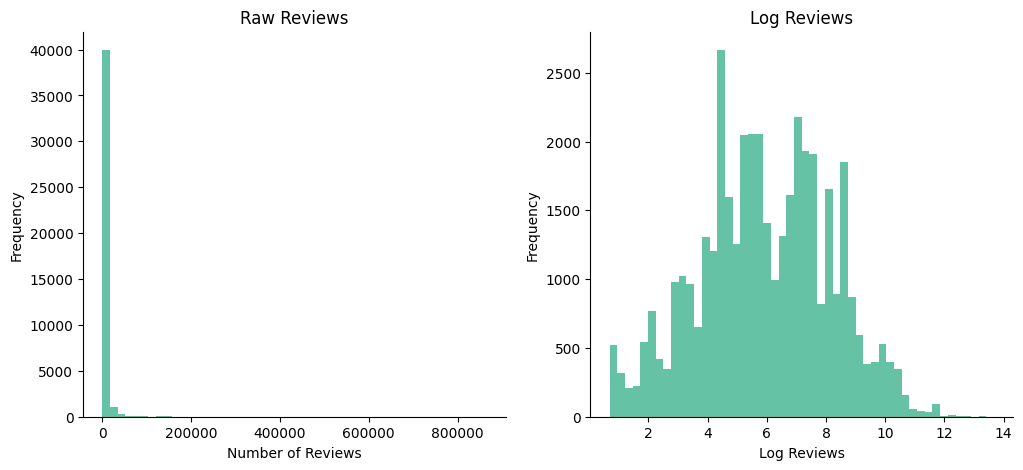

In [4]:
# ------ Feature engineering ------

# Discount percentage (only where both prices exist)
df["discount_percentage"] = (
    (df["listed_price"] - df["current_price"]) / df["listed_price"]
) * 100

# Discount buckets for grouped analysis
df["discount_bucket"] = pd.cut(
    df["discount_percentage"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 100],
    labels=["0-10%","10-20%","20-30%","30-40%","40-50%","50-60%","60-70%","70%+"]
)

# Price tier categories
df["price_category"] = pd.cut(
    df["current_price"],
    bins=[0, 25, 75, 200, 5000],
    labels=["Low (<$25)", "Mid ($25-75)", "High ($75-200)", "Premium (>$200)"]
)
# Boolean flags from text columns
df["is_best_seller_flag"] = df["is_best_seller"].str.contains("Best Seller", na=False).astype(int)
df["is_sponsored_flag"]   = (df["is_sponsored"] == "Sponsored").astype(int)
df["has_coupon_flag"]     = (~df["is_couponed"].str.contains("No Coupon", na=True)).astype(int)

# Log-transformed reviews (to handle strong right skew)
df["log_reviews"] = np.log1p(df["number_of_reviews"])

print("Feature engineering complete.")
print(f"Products with discount data: {df['discount_percentage'].notna().sum():,}")
print(f"Products with rating data:   {df['rating_numeric'].notna().sum():,}")
print(f"Best Sellers: {df['is_best_seller_flag'].sum():,} | Sponsored: {df['is_sponsored_flag'].sum():,} | Couponed: {df['has_coupon_flag'].sum():,}")

#Comparing log-transformed reviews with raw reviews
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(df["number_of_reviews"], bins=50)
ax[0].set_ylabel("Frequency")
ax[0].set_xlabel("Number of Reviews")
ax[0].set_title("Raw Reviews")
ax[1].hist(df["log_reviews"], bins=50)
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("Log Reviews")
ax[1].set_title("Log Reviews")
plt.show()

## 3. Exploratory Data Analysis

### 3.1 Rating Distribution

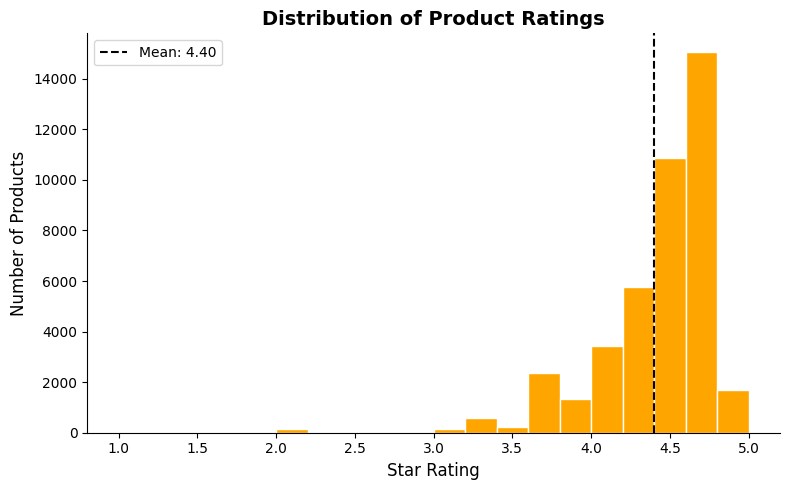

count    41651.00
mean         4.40
std          0.39
min          1.00
25%          4.20
50%          4.50
75%          4.70
max          5.00
Name: rating_numeric, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["rating_numeric"].dropna(), bins=20, color='orange', edgecolor='white')
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("Number of Products", fontsize=12)
ax.set_title("Distribution of Product Ratings", fontsize=14, fontweight='bold')
ax.axvline(df["rating_numeric"].mean(), color='black', linestyle='--',
           label=f'Mean: {df["rating_numeric"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()
print(df["rating_numeric"].describe().round(2))

**Finding:** Ratings are heavily left-skewed with a mean of ~4.4. The vast majority of products have ratings between 4.0 and 5.0, which is typical of Amazon's review ecosystem where negative experiences are often not reviewed.

### 3.2 Summary Statistics for Key Metrics

In [6]:
df[[
    "current_price", "listed_price", "discount_percentage",
    "rating_numeric", "number_of_reviews", "bought_last_month_numeric"
]].describe().round(2)

,current_price,listed_price,discount_percentage,rating_numeric,number_of_reviews,bought_last_month_numeric
count,30926.00,12311.00,12311.00,41651.00,41651.00,32233.00
mean,212.61,214.46,21.60,4.40,3087.11,169.42
std,389.89,443.52,14.52,0.39,13030.46,163.24
min,2.49,4.95,4.50,1.00,1.00,1.00
25%,25.99,27.33,10.01,4.20,82.00,50.00
50%,77.00,59.99,17.67,4.50,343.00,100.00
75%,197.95,185.00,30.01,4.70,1886.00,200.00
max,4699.00,5399.00,85.42,5.00,865598.00,900.00


## 4. Business Question Analysis

### Q1: Does a higher discount correlate with more reviews (engagement)?

In [7]:
# Group by discount bucket and look at median reviews
disc_engagement = (
    df.groupby("discount_bucket", observed=True)["number_of_reviews"]
    .agg(["median", "count"])
    .reset_index()
)
disc_engagement.columns = ["Discount Range", "Median Reviews", "Product Count"]
print(disc_engagement.to_string(index=False))

Discount Range  Median Reviews  Product Count
         0-10%           381.0           2840
        10-20%           579.0           3937
        20-30%          1117.0           2299
        30-40%           977.5           1776
        40-50%           694.0            599
        50-60%           142.0            533
        60-70%          1135.0             17
          70%+            14.0            139


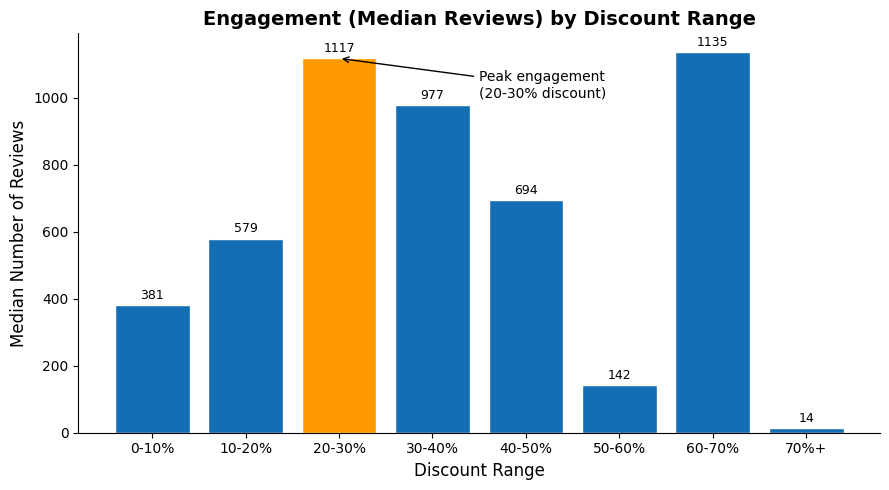

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FF9900' if r == '20-30%' else '#146EB4' for r in disc_engagement["Discount Range"].astype(str)]
bars = ax.bar(disc_engagement["Discount Range"].astype(str),
              disc_engagement["Median Reviews"], color=colors, edgecolor='white')
ax.set_xlabel("Discount Range", fontsize=12)
ax.set_ylabel("Median Number of Reviews", fontsize=12)
ax.set_title("Engagement (Median Reviews) by Discount Range", fontsize=14, fontweight='bold')
ax.annotate("Peak engagement\n(20-30% discount)", xy=(2, 1117), xytext=(3.5, 1000),
            arrowprops=dict(arrowstyle="->", color='black'), fontsize=10)
for bar, val in zip(bars, disc_engagement["Median Reviews"]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{int(val)}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
# Pearson correlation (raw)
raw_corr = df[["discount_percentage","number_of_reviews"]].corr().iloc[0,1]
# Log-reviews correlation
subset_d = df.dropna(subset=["discount_percentage","number_of_reviews"]).copy()
subset_d["log_reviews"] = np.log1p(subset_d["number_of_reviews"])
log_corr = subset_d[["discount_percentage","log_reviews"]].corr().iloc[0,1]
print(f"Pearson correlation (raw reviews):  r = {raw_corr:.4f}")
print(f"Pearson correlation (log reviews):  r = {log_corr:.4f}")

Pearson correlation (raw reviews):  r = -0.0119
Pearson correlation (log reviews):  r = -0.0569


**Finding:** There is a **non-linear relationship** between discount level and engagement.

- Products discounted **20–30%** show the highest median review count (~1,117), suggesting these are popular, established products that happen to be moderately promoted.
- Products with **extreme discounts (70%+)** have very low engagement (median ~14 reviews), likely representing overstock or underperforming inventory.
- The raw Pearson correlation is near zero (r ≈ -0.01), confirming the non-linear pattern — simple correlation misses the story here.

**Interpretation:** Moderate discounts don't *cause* high engagement; instead, high-engagement products are more likely to receive moderate promotional discounts. Extreme discounts signal poor demand.

### Q2: Do higher-rated products attract more engagement?

In [10]:
subset = df.dropna(subset=["rating_numeric", "number_of_reviews"]).copy()
subset["log_reviews"] = np.log1p(subset["number_of_reviews"])

# Correlations
raw_r = subset[["rating_numeric","number_of_reviews"]].corr().iloc[0,1]
log_r = subset[["rating_numeric","log_reviews"]].corr().iloc[0,1]
print(f"Correlation (rating vs raw reviews):  r = {raw_r:.4f}")
print(f"Correlation (rating vs log reviews):  r = {log_r:.4f}  ← more meaningful due to skew")

Correlation (rating vs raw reviews):  r = 0.0998
Correlation (rating vs log reviews):  r = 0.2122  ← more meaningful due to skew


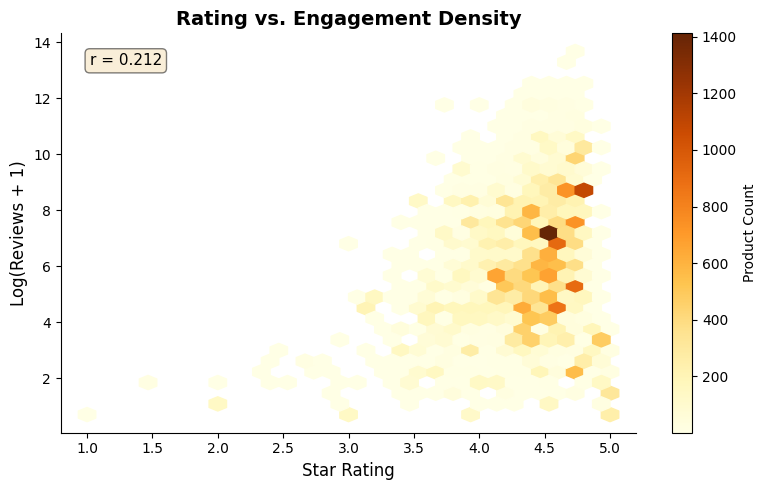

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(subset["rating_numeric"], subset["log_reviews"],
               gridsize=30, cmap='YlOrBr', mincnt=1)
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("Log(Reviews + 1)", fontsize=12)
ax.set_title("Rating vs. Engagement Density", fontsize=14, fontweight='bold')
ax.text(0.05, 0.95, f'r = {log_r:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.colorbar(hb, ax=ax, label='Product Count')
plt.tight_layout()
plt.show()

**Finding:** After adjusting for the strong right-skew in the review distribution (using log transformation), a **modest positive relationship** emerges between rating and engagement (r ≈ 0.21).

Higher-rated products tend to accumulate more reviews over time — likely due to positive word-of-mouth and algorithmic promotion — but the relationship is not strong, suggesting other factors (price, category, marketing) play a larger role in driving volume.

### Q3: Are low-priced products more likely to receive extreme ratings?

In [12]:
# Compare rating distributions: bottom 25% vs top 25% by price
q25 = df["current_price"].quantile(0.25)
q75 = df["current_price"].quantile(0.75)

low_price  = df[df["current_price"] <= q25]["rating_numeric"].dropna()
high_price = df[df["current_price"] >= q75]["rating_numeric"].dropna()

def extreme_pct(series):
    return ((series <= 2.0) | (series >= 4.8)).mean() * 100

print(f"Price threshold — Low: ≤ ${q25:.0f}  |  High: ≥ ${q75:.0f}")
print(f"Low price  — mean rating: {low_price.mean():.2f}, extreme ratings: {extreme_pct(low_price):.1f}%")
print(f"High price — mean rating: {high_price.mean():.2f}, extreme ratings: {extreme_pct(high_price):.1f}%")

# Statistical test
t_stat, p_val = stats.ttest_ind(low_price, high_price)
print(f"\nT-test: t = {t_stat:.2f}, p = {p_val:.2e} ({'significant' if p_val < 0.05 else 'not significant'})")

Price threshold — Low: ≤ $26  |  High: ≥ $198
Low price  — mean rating: 4.62, extreme ratings: 32.6%
High price — mean rating: 4.28, extreme ratings: 11.9%

T-test: t = 52.57, p = 0.00e+00 (significant)


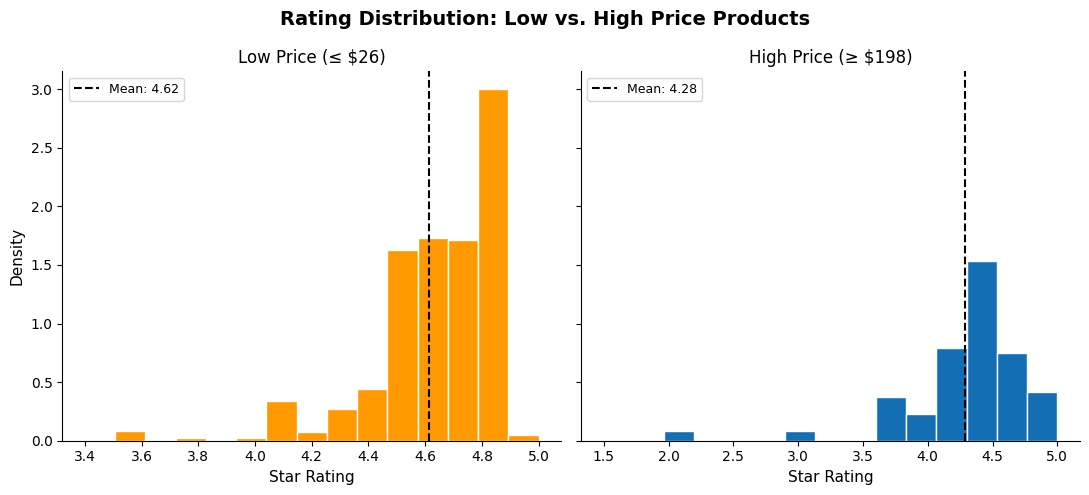

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, data, label, color in zip(
    axes,
    [low_price, high_price],
    [f'Low Price (≤ ${q25:.0f})', f'High Price (≥ ${q75:.0f})'],
    ['#FF9900', '#146EB4']
):
    ax.hist(data, bins=15, color=color, edgecolor='white', density=True)
    ax.set_xlabel("Star Rating", fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.axvline(data.mean(), color='black', linestyle='--',
               label=f'Mean: {data.mean():.2f}')
    ax.legend(fontsize=9)
axes[0].set_ylabel("Density", fontsize=11)
fig.suptitle("Rating Distribution: Low vs. High Price Products", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Low-priced products show a significantly higher rate of extreme ratings (~33% receive ≥4.8 or ≤2.0 stars) compared to high-priced products (~12%).

This is consistent with two effects:
1. **Polarization:** Low-cost, impulse-buy products tend to generate either delight ("great value!") or disappointment ("cheap junk"), with fewer moderate reviews.
2. **Expectation calibration:** Premium products attract more discerning buyers who rate more moderately.

The difference is statistically significant (p < 0.001).

### Q4: Do sponsored products perform differently than organic ones?

In [14]:
sponsored   = df[df["is_sponsored"] == "Sponsored"]
organic     = df[df["is_sponsored"] == "Organic"]

metrics = ["rating_numeric", "number_of_reviews", "bought_last_month_numeric"]
comp = pd.DataFrame({
    "Sponsored":  sponsored[metrics].median(),
    "Organic":    organic[metrics].median()
}).round(2)
comp.index = ["Median Rating", "Median Reviews", "Median Bought Last Month"]
print(comp)

                          Sponsored  Organic
Median Rating                   4.5      4.5
Median Reviews                180.0    383.0
Median Bought Last Month       20.0    100.0


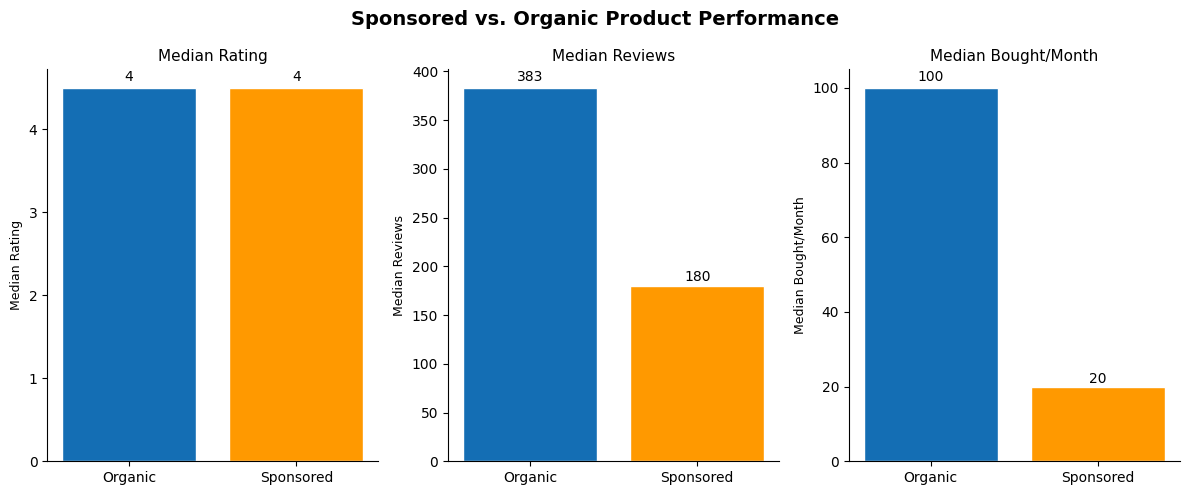

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
labels = ["Median Rating", "Median Reviews", "Median Bought/Month"]
cols   = ["rating_numeric", "number_of_reviews", "bought_last_month_numeric"]
colors = {"Sponsored": "#FF9900", "Organic": "#146EB4"}

for ax, col, label in zip(axes, cols, labels):
    medians = df.groupby("is_sponsored")[col].median()
    medians = medians.reindex(["Organic", "Sponsored"])
    bars = ax.bar(medians.index, medians.values,
                  color=[colors["Organic"], colors["Sponsored"]], edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    for bar, val in zip(bars, medians.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()*1.01,
                f'{val:.0f}', ha='center', va='bottom', fontsize=10)

fig.suptitle("Sponsored vs. Organic Product Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Organic products outperform sponsored products on all engagement metrics:
- Organic products have **2× more median reviews** (383 vs. 180)
- Organic products also have higher bought-last-month figures

Ratings are essentially equal (both ~4.5 median). This suggests that **sponsored placement does not improve a product's intrinsic quality signals**, and that sponsorship tends to be used by newer or less-established products trying to gain visibility.

## 5. Export Clean Data for Power BI

Export a clean, analysis-ready CSV that can be directly imported into Power BI.

In [17]:
# Select and rename columns for Power BI
export_cols = {
    "title":                   "product_title",
    "rating_numeric":          "rating",
    "number_of_reviews":       "review_count",
    "bought_last_month_numeric": "bought_last_month",
    "current_price":           "current_price_usd",
    "listed_price":            "listed_price_usd",
    "discount_percentage":     "discount_pct",
    "discount_bucket":         "discount_range",
    "price_category":          "price_tier",
    "is_best_seller_flag":     "is_best_seller",
    "is_sponsored_flag":       "is_sponsored",
    "has_coupon_flag":         "has_coupon",
    "log_reviews":             "log_review_count",
    "collected_at":            "data_collected_at",
}

df_export = df[list(export_cols.keys())].rename(columns=export_cols)

# Add high_rating flag for Power BI filtering
df_export["high_rating"] = (df_export["rating"] >= 4.0).astype(int)
df_export['high_rating'] = df_export['high_rating'].map({0: 'Low Rating (<4.0)', 1: 'High Rating (≥4.0)'})
df_export["high_discount"] = (df_export["discount_pct"] >= df_export["discount_pct"].median()).astype(int)
df_export['high_discount'] = df_export['high_discount'].map({0: 'Low Discount', 1: 'High Discount'})
df_export['has_coupon'] = df_export['has_coupon'].astype(int).map({0: 'No Coupon', 1: 'Has Coupon'})
# Add review_bucket so its easier to see the connection with bought_last_month instead of doing it with review_count directly
df_export['review_bucket'] = pd.cut(df_export['review_count'], 
    bins=[0, 100, 1000, 10000, float('inf')], 
    labels=['A: 0-100', 'B: 100-1K', 'C: 1K-10K', 'D: 10K+'],
    include_lowest=True)
# Fix is_sponsored labels
df_export['is_sponsored'] = df_export['is_sponsored'].astype(int).map({0: 'Organic', 1: 'Sponsored'})
# Fix price_tier nulls
df_export = df_export.dropna(subset=['price_tier'])

df_export.to_csv("amazon_analysis_powerbi.csv", index=False)
print(f"Exported {len(df_export):,} rows to amazon_analysis_powerbi.csv")
print(f"Columns: {df_export.columns.tolist()}")
df_export.head(3)

Exported 30,926 rows to amazon_analysis_powerbi.csv
Columns: ['product_title', 'rating', 'review_count', 'bought_last_month', 'current_price_usd', 'listed_price_usd', 'discount_pct', 'discount_range', 'price_tier', 'is_best_seller', 'is_sponsored', 'has_coupon', 'log_review_count', 'data_collected_at', 'high_rating', 'high_discount', 'review_bucket']


,product_title,rating,review_count,bought_last_month,current_price_usd,listed_price_usd,discount_pct,discount_range,price_tier,is_best_seller,is_sponsored,has_coupon,log_review_count,data_collected_at,high_rating,high_discount,review_bucket
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,43.597484,40-50%,High ($75-200),0,Sponsored,Has Coupon,5.929589,2025-08-21 11:14:29,High Rating (≥4.0),High Discount,B: 100-1K
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6.0,9.99,15.99,37.523452,30-40%,Low (<$25),0,Sponsored,No Coupon,7.807103,2025-08-21 11:14:29,High Rating (≥4.0),High Discount,C: 1K-10K
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2.0,314.00,349.00,10.028653,10-20%,Premium (>$200),0,Sponsored,No Coupon,8.021256,2025-08-21 11:14:29,High Rating (≥4.0),Low Discount,C: 1K-10K


## 6. Summary of Findings

| Business Question | Answer |
|---|---|
| Does discount level correlate with engagement? | **Non-linear.** 20–30% discounts peak at 1,117 median reviews. Extreme discounts (70%+) have very low engagement (~14 reviews). |
| Do higher-rated products get more reviews? | **Modest positive relationship** (r = 0.21 on log scale). Rating explains engagement partially, but other factors dominate. |
| Are low-priced products more polarizing? | **Yes.** 33% of low-price products have extreme ratings vs. 12% of high-price products (p < 0.001). |
| Do sponsored products perform better? | **No.** Organic products have ~2× more reviews and higher sales velocity. Sponsorship compensates for lower organic visibility. |